In [155]:
"""------------------------------------------------------
 File Name: ToughApprox.py
 Goal: Find a function hard to approximate with a SNN
 Author: Francesca Cannata
---------------------------------------------------------"""

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt
import numpy as np
import math
import copy

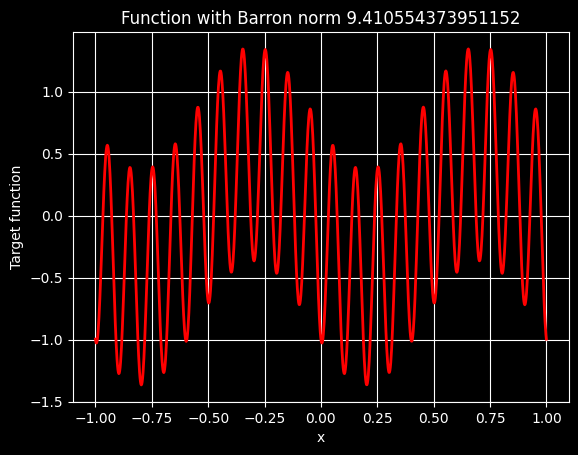

In [55]:
"""------------------------------------------
 Goal: Create a function hard to approximate
       with two frequency components
---------------------------------------------"""
# In order to have the same random generation each time
np.random.seed(0)

# Parameters
N = 2**10
s=1                 # power for the weight
omega1 = 1          # low frequency
omega2 = 10         # high frequency
phi1 = np.random.uniform(0, 2*math.pi)  # phase shift
phi2 = np.random.uniform(0, 2*math.pi)  # phase shift
w1 = (1+np.abs(omega1)**2)**(s/2)            # weight function
w2 = (1+np.abs(omega2)**2)**(s/2)            # weight function
F1 = 0.5                                     # amplitude
F2 = np.sqrt(1-F1**2)                        # amplitude -> Normalization : F1^2 + F2^2 = 1 (Parseval's theorem)

# Evaluate the Barron norm (p = 1)
barron_norm = F1*w1 + F2*w2

# Spatial domain
x = torch.linspace(-1,1,N).view(-1, 1)

# Create the function we want to approximate
y = F1 * torch.sin(2*math.pi*omega1*x + phi1) + F2 * torch.sin(2*math.pi*omega2*x + phi2)

# Visualization
fig = plt.figure(1)
plt.plot(x, y, color='red', linewidth=2)
plt.title(f'Function with Barron norm {barron_norm}')
plt.xlabel('x')
plt.ylabel('Target function')
plt.grid(True)

The best model is OrderedDict({'InHid1.weight': tensor([[0.9171],
        [0.8976]]), 'InHid1.bias': tensor([-0.8529,  0.1598]), 'Hid1Out.weight': tensor([[-0.0365, -0.3905]]), 'Hid1Out.bias': tensor([0.3796])})
The final epoch is 100/100 and the loss is 0.6139761209487915
The minimum loss is 0.6139761209487915 and its epoch is 100


Text(0.5, 1.0, 'Evolution of Loss (log scale)')

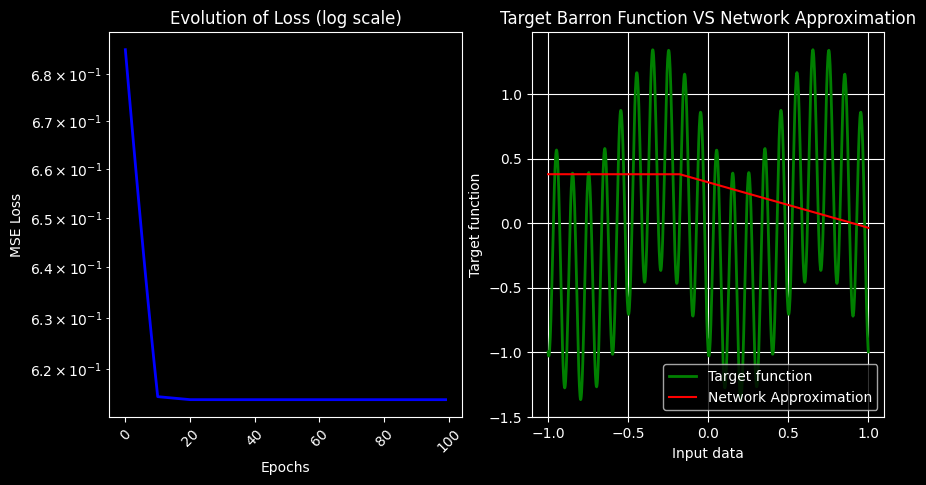

In [158]:
"""----------------------------------
 Goal: Build the SNN and train it
-------------------------------------"""


# ---------- Network Architecture and Model Definition ----------
# Define the number of neurons for each layer
n_in = 1
n_Hid1 = 2
n_out = 1

# Set the learning rate
learning_rate = 0.01

# Define a class which contains our training model.
class NeuralNet(nn.Module): # our class "NeuralNet" inherits all methods and properties from the superclass nn.Module in PyTorch
    def __init__(self):
        super().__init__() # initialization of nn.Module

        # Architecture of our network: two hidden layers with 2 and 3 neurons respectively and ReLU activation.
        # The function "nn.Linear(in_features, out_features)" applies an affine transformation to input data (x * W^T + b). It creates
        # the weight matrix of dimension (in_features, out_features) and the bias tensor of length in_features; it fills them with
        # random values. The bias argument is optional: by default is True, but one can disable it
        self.InHid1 = nn.Linear(n_in, n_Hid1)       # it creates the input-weight matrix with shape (n_in, n_Hid1) and the input-bias vector with size n_in
        self.Hid1Out = nn.Linear(n_Hid1, n_out)     # it creates the output-weight matrix with shape (n_Hid1, n_out) and the output-bias vector with size n_Hid1
        self.activation = nn.ReLU()                 # examples of non-linear activation functions: nn.ReLU(), nn.Tanh(), nn.Sigmoid(), nn.ELU() etc.

    # We need a function for establishing the order in which our data go through the layers
    # and for turning the input to the network (x) to its output
    def forward(self, x):
        x = self.activation(self.InHid1(x)) # input -> 1st Hidden: 1. With "self.InHid1(x)" each input x is multiplied by the input-weight and added to
                                            #                         the input-bias.
                                            #                      2. With "self.activation()", the net is applying the activation function to the result of
                                            #                         the previous step. They will get the new input x for the 1st-hidden layer.
        x = self.Hid1Out(x) # 2st Hidden -> output
        return x

# Define the model
model = NeuralNet()

# Create the loss function (we are taking the Mean Square Error MSE).
error = nn.MSELoss()

# Create the optimizer: it changes the "model.parameters()" (== the parameters of the network)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Change the learning rate dynamically with the Scheduler algorithm: we want to adjust it during the training (Step Decay = StepLR or Exponential Decay = ExponentialLR)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma= 0.01)

# Create and visualize a dictonary with all network's parameters
# dict_Net_Param = model.state_dict()
# for key, value in dict_Net_Param.items():
#    print(f'Parameter: {key}. Values: {value} \n')



# Parameter's initialization
with torch.no_grad():
    # Bias
    nn.init.uniform_(model.InHid1.bias, a=-1, b=1)
    #print(f'Initialized bias: {model.InHid1.bias}')

    # Weight -> random +-1 value
    init_weights = torch.where(model.InHid1.weight <= 0, -1, 1)
    #print(init_weights)
    model.InHid1.weight.copy_(init_weights)
    #print(f'Initialized weight: {model.InHid1.weight}')


# ---------- Training Loop ----------
min_loss = np.ones(2) # initialization of the array which will contain the minimum loss
best_model = {}       # initialization of the dictionary which will contain the best model

epochs = 100
loss_history = np.zeros(epochs) # initialization of the array which will contain all errors
for epoch in range(epochs):

    # Reset gradients in order to not accumulate them in the .grad attribute during next epochs
    optimizer.zero_grad()

    # Forward pass: compute predicted output y_pred passing the input data x_tensor to our model
    y_pred = model(x)

    # Compare the prediction y_pred to the target y_tensor evaluating the loss. We want it goes near to zero as much as possible
    loss = error(y_pred, y)
    # print(f"For epoch ", epoch, " the loss is: ", loss.item())    # "loss.item()" gives us just the number inside the tensor.
                                                                    # Otherwise, if we print "loss", we will see the number and its derivation


    # Backward pass: determine how much each parameter contribute to the error. To this end, we compute the
    # derivatives of the error function with respect to every model parameter. It starts from the back to the start.
    # It stores the result for each parameter in their ".grad()" attribute
    loss.backward()

    # Gradient descent: update the parameters in the direction stored in .grad() attribute
    optimizer.step()

    # Update the learning rate when reaching the "step_size"
    scheduler.step()

    # Keep track of the minimum loss and the corresponding model
    aux_loss = [epoch, loss.item()] # auxiliary array with the epoch and the corresponding loss
    if aux_loss[1] <= min_loss[1]:
        min_loss = [epoch, aux_loss[1]]

        best_model = copy.deepcopy(model.state_dict())      # in order to have a copy (and not a reference) we need to use "copy.deepcopy()"

    # add the loss to the array
    loss_history[epoch] = loss.item()

# To be sure the net uses the best model found, we load it with "model.load_state_dict()"
model.load_state_dict(best_model)

print(f"The best model is {best_model}")

# ---------- Visualization ----------

# Compute the prediction corresponding to the last epoch, without Autograd tracking
with torch.no_grad(): # all commands in here, will be without attribute "grad_fn"
    y_pred_final = model(x).numpy() # we are converting the tensor to a numpy array just for making the plot

# Print the final epoch with the corresponding loss
print(f"The final epoch is {(epoch+1)}/{epochs} and the loss is {(loss.item())}")

# Print the minimum loss and its epoch
print(f"The minimum loss is {(min_loss[1])} and its epoch is {(min_loss[0]+1)}")

# Final plot
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[1].plot(x, y, label='Target function', color='green', linewidth=2)
ax[1].plot(x, y_pred_final, label='Network Approximation', color='red')

# Plots attributes
ax[1].set_xlabel('Input data')
ax[1].set_ylabel('Target function')
ax[1].set_title('Target Barron Function VS Network Approximation')
ax[1].legend(loc='best')
ax[1].grid(True)

ax[0].semilogy(loss_history, label='Training Loss', color='blue', linewidth=2)
ax[0].set_xlabel('Epochs')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_ylabel('MSE Loss')
ax[0].set_title('Evolution of Loss (log scale)')


2484 are inside the range


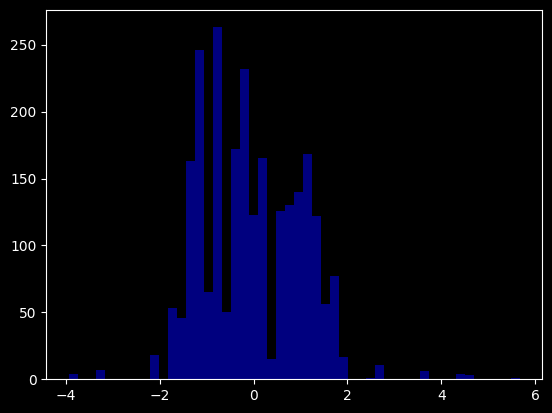

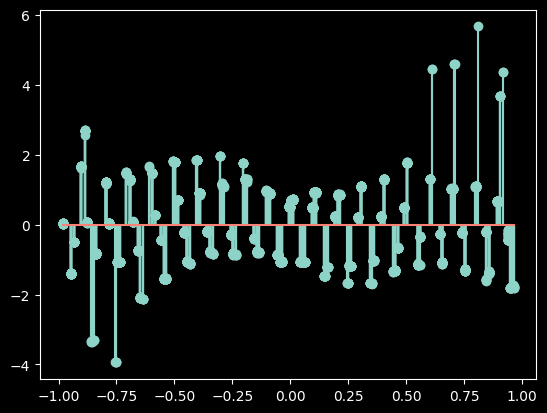

In [145]:
# Position of activated neurons:  0 = y = weight * x + bias =>  x = - bias/weight
zero_pos = -model.InHid1.bias.flatten()/model.InHid1.weight.flatten()

# Select the activated neurons whose position is between -1 and 1
pos_in_range = torch.bitwise_and(zero_pos >= -1.0, zero_pos <= 1.0)

# Select the weights associate to the activated neurons
weight_in_range = model.Hid1Out.weight.flatten()[pos_in_range]

# Plot of activated weights
plt.figure(1)
plt.hist(weight_in_range.detach().numpy(), bins=50, color='blue', alpha=0.5, label='Weight')

# Plot of activated neurons
plt.figure(2)
plt.stem(zero_pos[pos_in_range].detach(), weight_in_range.detach(), label='Weight')

# Print how many neurons are activated between -1 and 1
print(f'{torch.sum(pos_in_range)} are inside the range')